# 인천 3개 구 아동·청소년 인구와 교육·돌봄 인프라 분석

- 대상 지역: 남동구, 미추홀구, 연수구
- 분석 흐름: **① 아동 인구 → ② 인구 구성 → ③ 동별 아동 분포 → ④ 공공 돌봄·취약성 인프라 → ⑤ 사교육 보조 비교**
- 이 노트북은 인프라가 인구 유입이나 교육성과를 유발했다고 단정하지 않고, 인구 대비 공급의 차이를 진단합니다.

In [27]:
from pathlib import Path
import pandas as pd

AREAS = ("남동구", "미추홀구", "연수구")
FILE_TEMPLATE = "2025_인천시_지역별 아동,청소년,청년 인구현황_{}.csv"
REQUIRED_COLUMNS = {"행정구역", "2025년_전체", "2025년_아동전체"}


def resolve_data_dir():
    """노트북을 저장소 루트나 mini-project 폴더에서 실행해도 CSV를 찾는다."""
    candidates = (Path.cwd(), Path.cwd() / "mini-project")
    for candidate in candidates:
        if all((candidate / FILE_TEMPLATE.format(area)).exists() for area in AREAS):
            return candidate
    raise FileNotFoundError("분석에 필요한 3개 CSV 파일을 찾을 수 없습니다.")


def _preprocess(raw_df):
    df = raw_df.copy()
    missing = REQUIRED_COLUMNS - set(df.columns)
    if missing:
        raise ValueError(f"필수 열이 없습니다: {sorted(missing)}")

    numeric_columns = [column for column in df.columns if column != "행정구역"]
    df[numeric_columns] = df[numeric_columns].apply(
        lambda column: pd.to_numeric(
            column.astype(str).str.replace(",", "", regex=False),
            errors="raise",
        )
    )
    df["구"] = df["행정구역"].str.extract(r"인천광역시\s+([가-힣]+구)")
    # 공백과 괄호가 아닌 모든 문자를 허용해 '도화2.3동'도 온전히 보존한다.
    df["동"] = df["행정구역"].str.extract(r"\s([^\s()]+동)\(")
    df["아동비율"] = df["2025년_아동전체"] / df["2025년_전체"] * 100
    return df


def _validate_population_data(population_df):
    if population_df["행정구역"].duplicated().any():
        raise ValueError("중복된 행정구역이 있습니다.")

    for area in AREAS:
        area_df = population_df.loc[population_df["구"] == area]
        total_rows = area_df.loc[area_df["동"].isna()]
        dong_rows = area_df.loc[area_df["동"].notna()]
        if len(total_rows) != 1:
            raise ValueError(f"{area} 구 총계 행은 정확히 1개여야 합니다.")
        for column in ("2025년_전체", "2025년_아동전체"):
            if int(total_rows.iloc[0][column]) != int(dong_rows[column].sum()):
                raise ValueError(f"{area}의 {column} 구 총계와 동 합계가 다릅니다.")


def load_population_data(data_dir):
    frames = []
    for area in AREAS:
        path = Path(data_dir) / FILE_TEMPLATE.format(area)
        frames.append(_preprocess(pd.read_csv(path, encoding="EUC-KR")))
    population_df = pd.concat(frames, ignore_index=True)
    _validate_population_data(population_df)
    return population_df


def build_gu_summary(population_df):
    return (
        population_df.loc[population_df["동"].isna()]
        .sort_values("2025년_아동전체", ascending=False)
        .reset_index(drop=True)
    )


def build_top5(population_df, n=5):
    dong_df = population_df.loc[population_df["동"].notna()]
    top_frames = []
    for area in AREAS:
        top_frames.append(
            dong_df.loc[dong_df["구"] == area]
            .nlargest(n, "2025년_아동전체")
            .sort_values("2025년_아동전체", ascending=False)
        )
    return pd.concat(top_frames, ignore_index=True)

In [28]:
data_dir = resolve_data_dir()
population_df = load_population_data(data_dir)
gu_summary = build_gu_summary(population_df)
top5_df = build_top5(population_df)

summary_table = gu_summary[["구", "2025년_전체", "2025년_아동전체", "아동비율"]].copy()
summary_table.columns = ["구", "전체 인구", "아동 인구", "아동 비율(%)"]
summary_table["전체 인구"] = summary_table["전체 인구"].map(lambda value: f"{value:,}명")
summary_table["아동 인구"] = summary_table["아동 인구"].map(lambda value: f"{value:,}명")
summary_table["아동 비율(%)"] = summary_table["아동 비율(%)"].map(lambda value: f"{value:.2f}%")
summary_table

,구,전체 인구,아동 인구,아동 비율(%)
0,연수구,"409,437명","71,191명",17.39%
1,남동구,"480,147명","58,973명",12.28%
2,미추홀구,"417,578명","48,481명",11.61%


## ① 구별 아동 인구수

각 구에 실제로 거주하는 아동의 절대 규모를 비교합니다. 전체 인구 규모가 서로 다르므로 다음 단계의 비율 그래프와 함께 해석해야 합니다.

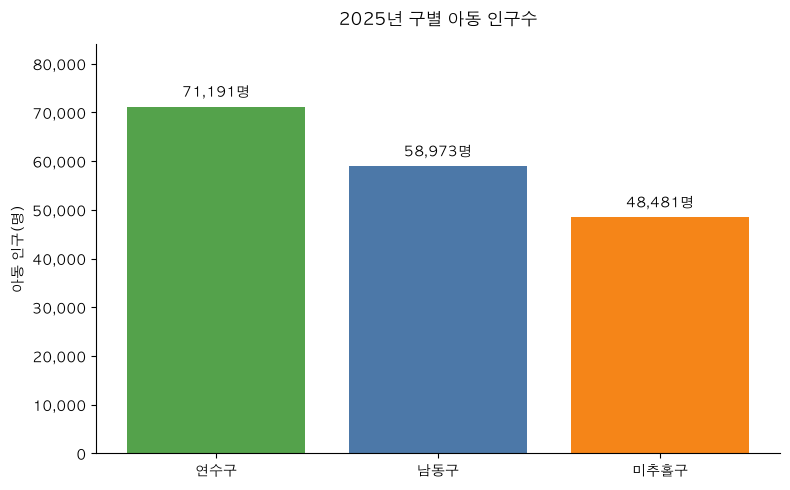

In [29]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

AREA_COLORS = {
    "남동구": "#4C78A8",
    "미추홀구": "#F58518",
    "연수구": "#54A24B",
}

plot_df = gu_summary.sort_values("2025년_아동전체", ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    plot_df["구"],
    plot_df["2025년_아동전체"],
    color=[AREA_COLORS[area] for area in plot_df["구"]],
)
ax.bar_label(bars, labels=[f"{value:,}명" for value in plot_df["2025년_아동전체"]], padding=4)
ax.set_title("2025년 구별 아동 인구수", pad=14, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("아동 인구(명)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax.set_ylim(0, plot_df["2025년_아동전체"].max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## ② 전체 인구 대비 아동 비율

구의 인구 규모 차이를 제거하고, 주민 100명 중 아동이 몇 명인지 비교합니다. 남동구도 CSV에 전체 인구가 있으므로 실제 값으로 계산합니다.

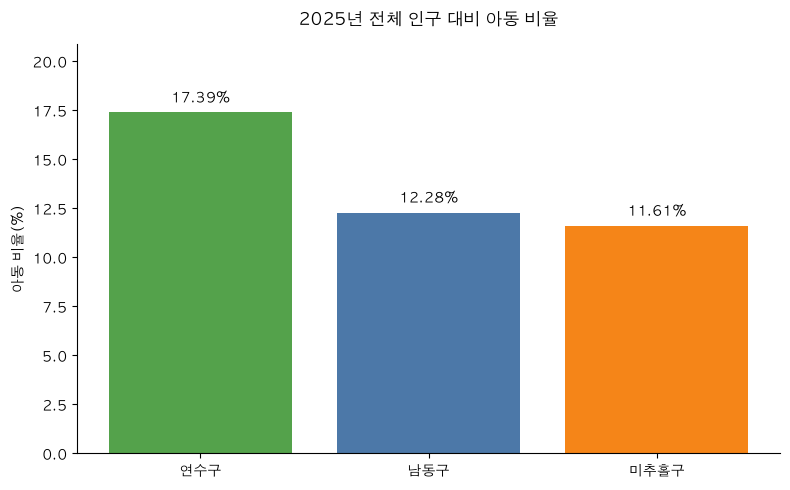

In [30]:
plot_df = gu_summary.sort_values("아동비율", ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    plot_df["구"],
    plot_df["아동비율"],
    color=[AREA_COLORS[area] for area in plot_df["구"]],
)
ax.bar_label(bars, labels=[f"{value:.2f}%" for value in plot_df["아동비율"]], padding=4)
ax.set_title("2025년 전체 인구 대비 아동 비율", pad=14, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("아동 비율(%)")
ax.set_ylim(0, plot_df["아동비율"].max() * 1.2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## ③ 구별 행정동 아동 인구 Top 5

각 구 안에서 아동 인구수가 많은 행정동 5곳을 비교합니다. 이 순위는 **아동 비율이 아니라 아동 인구수** 기준입니다.

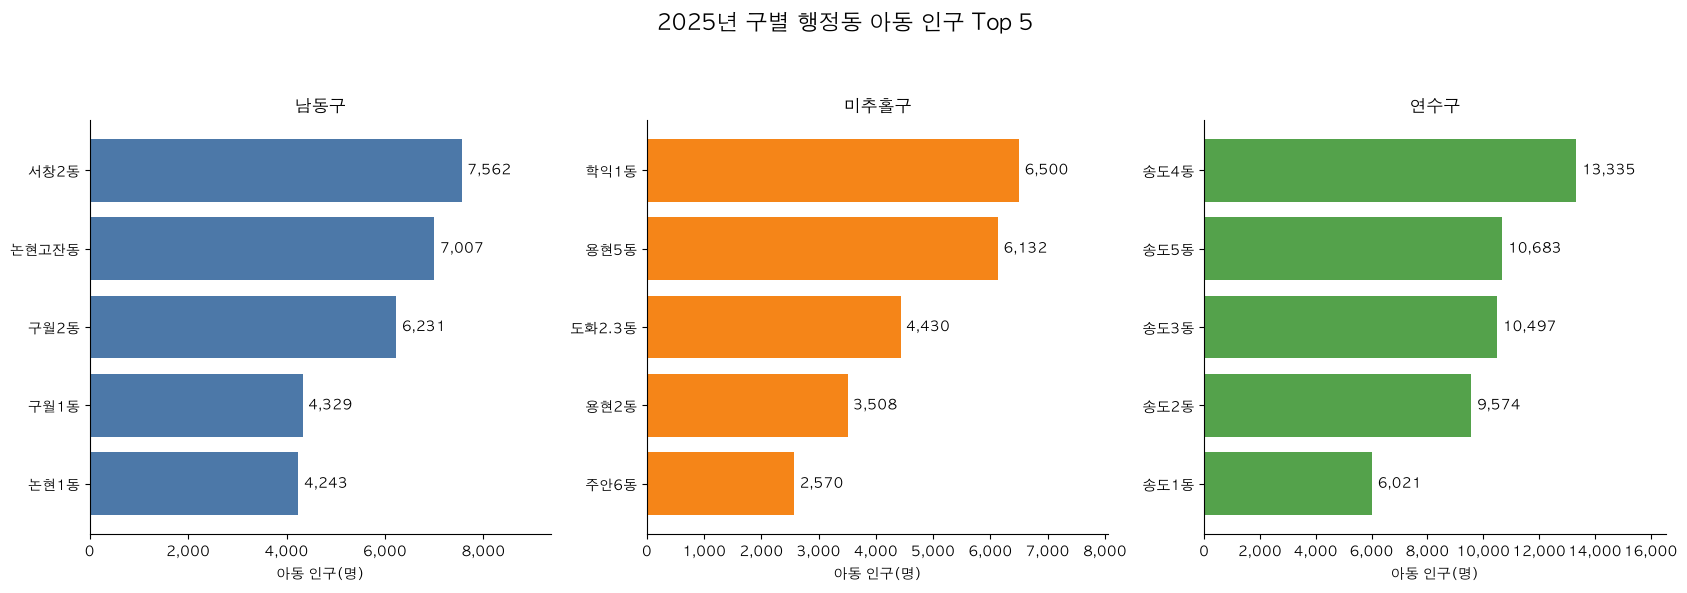

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharex=False)

for ax, area in zip(axes, AREAS):
    area_top5 = (
        top5_df.loc[top5_df["구"] == area]
        .sort_values("2025년_아동전체", ascending=True)
    )
    bars = ax.barh(
        area_top5["동"],
        area_top5["2025년_아동전체"],
        color=AREA_COLORS[area],
    )
    ax.bar_label(bars, labels=[f"{value:,}" for value in area_top5["2025년_아동전체"]], padding=4)
    ax.set_title(area, weight="bold")
    ax.set_xlabel("아동 인구(명)")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
    ax.set_xlim(0, area_top5["2025년_아동전체"].max() * 1.24)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("2025년 구별 행정동 아동 인구 Top 5", fontsize=16, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 기존 인구 분석 결과

- **연수구**는 아동 인구가 71,191명으로 가장 많고, 전체 인구 대비 아동 비율도 17.39%로 가장 높습니다.
- **남동구**는 전체 인구가 480,147명으로 가장 크지만, 아동 인구는 58,973명이고 아동 비율은 12.28%입니다.
- **미추홀구**는 아동 인구 48,481명, 아동 비율 11.61%로 세 구 중 가장 낮습니다.
- 연수구의 아동 인구 상위 행정동은 송도4동, 송도5동, 송도3동, 송도2동, 송도1동으로 송도 지역에 집중되어 있습니다.

절대 인구수와 비율은 서로 다른 질문에 답합니다. 따라서 두 그래프를 함께 제시해야 지역의 실제 아동 규모와 인구 구성상의 특징을 구분해 설명할 수 있습니다.

## ④ 인구 대비 공공 교육·돌봄 인프라

세 구에 공통으로 확보된 자료를 결합해 **아동·청소년 인구 규모**, **지역아동센터의 수용 역량**, **경제적 취약성 보조지표**를 비교합니다. 자료 기준일이 서로 다르므로 순위가 아닌 인구 대비 공급 구조를 읽는 데 사용합니다.

- 인구: 2025년
- 지역아동센터: 2024년 7월
- 국민기초생활수급자: 2025년 3월

In [32]:
RAW_DATA_DIR = data_dir / "data" / "raw"
if not RAW_DATA_DIR.exists():
    RAW_DATA_DIR = data_dir / "mini-project" / "data" / "raw"

CHILD_CENTER_PATH = RAW_DATA_DIR / "2024-07-31_incheon_child_centers.csv"
RECIPIENT_PATH = RAW_DATA_DIR / "2025-03-31_incheon_basic_livelihood_recipients.hwpx"
YEONSU_SCHOOL_PATH = RAW_DATA_DIR / "2026-04-01_yeonsu_school_status.csv"
SCHOOL_RESOURCES_PATH = RAW_DATA_DIR / "2025_three_gu_school_resources.csv"

for path in (CHILD_CENTER_PATH, RECIPIENT_PATH, YEONSU_SCHOOL_PATH, SCHOOL_RESOURCES_PATH):
    if not path.exists():
        raise FileNotFoundError(f"필요한 수집 자료가 없습니다: {path}")

child_centers = pd.read_csv(CHILD_CENTER_PATH, encoding="cp949")
recipients = pd.read_csv(RECIPIENT_PATH, encoding="cp949")
yeonsu_schools = pd.read_csv(YEONSU_SCHOOL_PATH, encoding="cp949")
school_resources = pd.read_csv(SCHOOL_RESOURCES_PATH, encoding="utf-8-sig")

if set(school_resources["구"]) != set(AREAS) or set(school_resources["학교급"]) != {"초등학교", "중학교"}:
    raise ValueError("학교 교육여건 자료에 세 구 또는 학교급별 행이 누락되었습니다.")

population_summary = gu_summary.set_index("구").reindex(AREAS).copy()
center_summary = (
    child_centers.loc[child_centers["군구명"].isin(AREAS)]
    .groupby("군구명")
    .agg(지역아동센터_수=("시설명", "size"), 지역아동센터_정원=("아동정원", "sum"))
    .reindex(AREAS, fill_value=0)
)
recipient_summary = (
    recipients.loc[(recipients["통계분류"] == "군구별") & recipients["세부항목"].isin(AREAS)]
    .set_index("세부항목")[["가구수", "수급자수"]]
    .reindex(AREAS)
)

infrastructure_summary = population_summary[["2025년_전체", "2025년_아동전체", "2025년_청소년전체"]].join(center_summary).join(recipient_summary)
infrastructure_summary["아동 1천 명당 센터 수"] = infrastructure_summary["지역아동센터_수"] / infrastructure_summary["2025년_아동전체"] * 1_000
infrastructure_summary["아동 1천 명당 센터 정원"] = infrastructure_summary["지역아동센터_정원"] / infrastructure_summary["2025년_아동전체"] * 1_000
infrastructure_summary["전체 인구 대비 수급자 비율(%)"] = infrastructure_summary["수급자수"] / infrastructure_summary["2025년_전체"] * 100

yeonsu_school_reference = (
    yeonsu_schools.groupby("구분")["학생수"].agg(["size", "sum"]).rename(columns={"size": "학교 수", "sum": "학생 수"})
)

infrastructure_summary.round(2)

,2025년_전체,2025년_아동전체,2025년_청소년전체,지역아동센터_수,지역아동센터_정원,가구수,수급자수,아동 1천 명당 센터 수,아동 1천 명당 센터 정원,전체 인구 대비 수급자 비율(%)
구,,,,,,,,,,
남동구,480147,58973,70918,41,1127,27267.0,38214.0,0.70,19.11,7.96
미추홀구,417578,48481,56320,14,380,22440.0,31366.0,0.29,7.84,7.51
연수구,409437,71191,72917,14,424,9727.0,13433.0,0.20,5.96,3.28


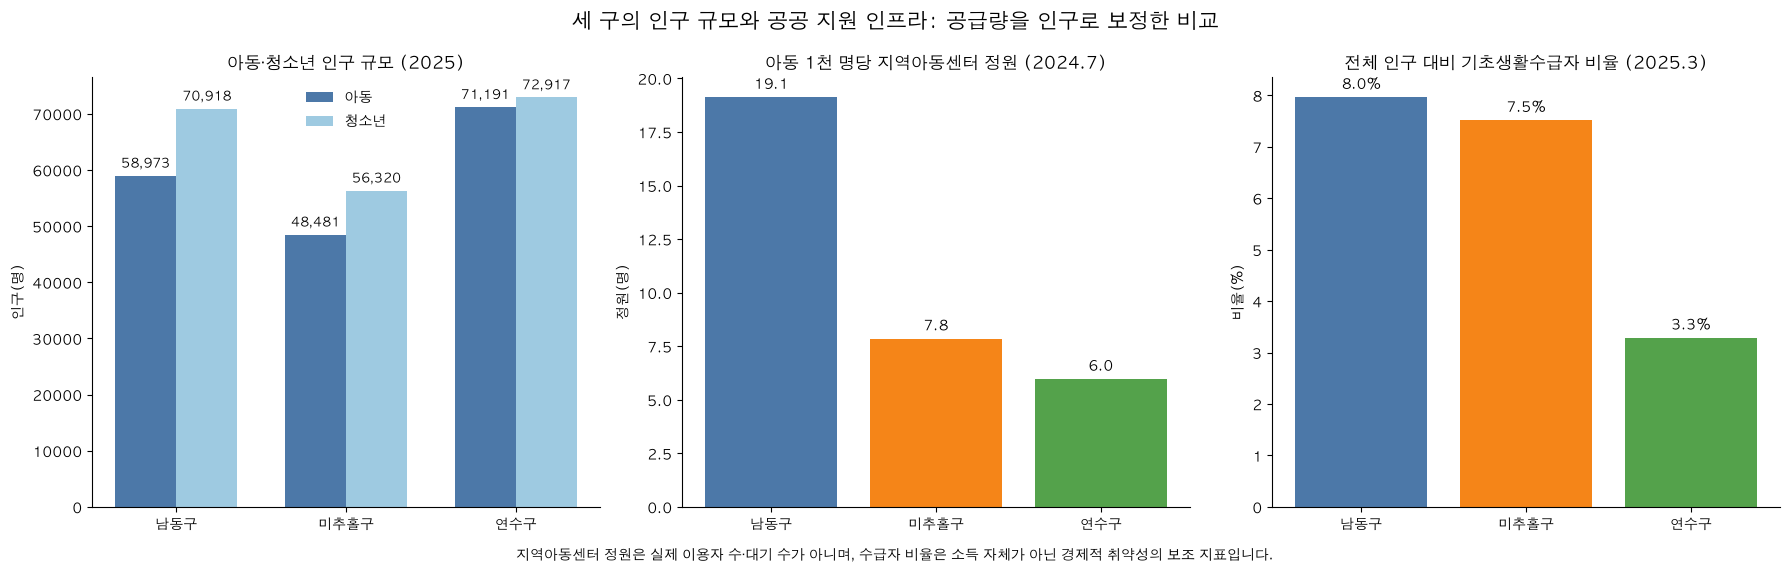

In [33]:
plot_df = infrastructure_summary.reset_index().rename(columns={"index": "구"})
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

x = range(len(plot_df))
width = 0.36
child_bars = axes[0].bar([value - width / 2 for value in x], plot_df["2025년_아동전체"], width, label="아동", color="#4C78A8")
teen_bars = axes[0].bar([value + width / 2 for value in x], plot_df["2025년_청소년전체"], width, label="청소년", color="#9ECAE1")
axes[0].bar_label(child_bars, labels=[f"{value:,.0f}" for value in plot_df["2025년_아동전체"]], padding=3, fontsize=9)
axes[0].bar_label(teen_bars, labels=[f"{value:,.0f}" for value in plot_df["2025년_청소년전체"]], padding=3, fontsize=9)
axes[0].set_xticks(list(x), plot_df["구"])
axes[0].set_title("아동·청소년 인구 규모 (2025)", weight="bold")
axes[0].set_ylabel("인구(명)")
axes[0].legend(frameon=False)

center_bars = axes[1].bar(plot_df["구"], plot_df["아동 1천 명당 센터 정원"], color=[AREA_COLORS[area] for area in plot_df["구"]])
axes[1].bar_label(center_bars, labels=[f"{value:.1f}" for value in plot_df["아동 1천 명당 센터 정원"]], padding=3)
axes[1].set_title("아동 1천 명당 지역아동센터 정원 (2024.7)", weight="bold")
axes[1].set_ylabel("정원(명)")

recipient_bars = axes[2].bar(plot_df["구"], plot_df["전체 인구 대비 수급자 비율(%)"], color=[AREA_COLORS[area] for area in plot_df["구"]])
axes[2].bar_label(recipient_bars, labels=[f"{value:.1f}%" for value in plot_df["전체 인구 대비 수급자 비율(%)"]], padding=3)
axes[2].set_title("전체 인구 대비 기초생활수급자 비율 (2025.3)", weight="bold")
axes[2].set_ylabel("비율(%)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("세 구의 인구 규모와 공공 지원 인프라: 공급량을 인구로 보정한 비교", fontsize=15, weight="bold")
fig.text(0.5, -0.02, "지역아동센터 정원은 실제 이용자 수·대기 수가 아니며, 수급자 비율은 소득 자체가 아닌 경제적 취약성의 보조 지표입니다.", ha="center", fontsize=10)
fig.tight_layout()
plt.show()

### 학교 교육여건: 학급·교원당 학생 수

2025년 인천교육통계에서 세 구의 초등학교와 중학교별 학생 수·학급 수·교원 수를 비교합니다. 이 지표는 수업과 개별 지원에 투입되는 자원의 규모를 보여 주지만, 교사의 수업 질이나 학생의 학업성취를 직접 나타내지는 않습니다.

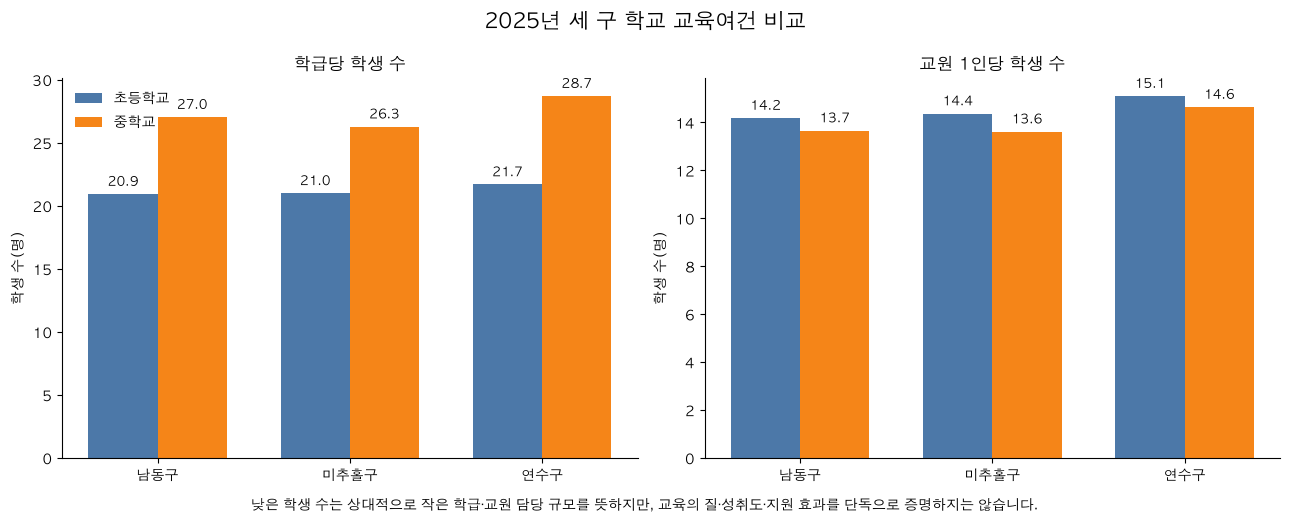

,구,학교급,학교수,학급수,학생수,교원수,학급당_학생수,교원1인당_학생수
3,남동구,중학교,22,524,14166,1037,27.03,13.66
4,미추홀구,중학교,12,300,7883,579,26.28,13.61
5,연수구,중학교,20,502,14407,984,28.70,14.64
0,남동구,초등학교,39,1038,21727,1532,20.93,14.18
1,미추홀구,초등학교,23,738,15490,1078,20.99,14.37
2,연수구,초등학교,34,1166,25288,1675,21.69,15.10


In [34]:
school_plot = school_resources.copy()
school_plot["구"] = pd.Categorical(school_plot["구"], categories=AREAS, ordered=True)
school_plot = school_plot.sort_values(["구", "학교급"])
elementary = school_plot.loc[school_plot["학교급"] == "초등학교"].set_index("구").reindex(AREAS)
middle = school_plot.loc[school_plot["학교급"] == "중학교"].set_index("구").reindex(AREAS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = range(len(AREAS))
width = 0.36

for ax, column, title, ylabel in [
    (axes[0], "학급당_학생수", "학급당 학생 수", "학생 수(명)"),
    (axes[1], "교원1인당_학생수", "교원 1인당 학생 수", "학생 수(명)"),
]:
    elementary_bars = ax.bar([value - width / 2 for value in x], elementary[column], width, label="초등학교", color="#4C78A8")
    middle_bars = ax.bar([value + width / 2 for value in x], middle[column], width, label="중학교", color="#F58518")
    ax.bar_label(elementary_bars, labels=[f"{value:.1f}" for value in elementary[column]], padding=3, fontsize=9)
    ax.bar_label(middle_bars, labels=[f"{value:.1f}" for value in middle[column]], padding=3, fontsize=9)
    ax.set_xticks(list(x), AREAS)
    ax.set_title(title, weight="bold")
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].legend(frameon=False)
fig.suptitle("2025년 세 구 학교 교육여건 비교", fontsize=15, weight="bold")
fig.text(0.5, -0.02, "낮은 학생 수는 상대적으로 작은 학급·교원 담당 규모를 뜻하지만, 교육의 질·성취도·지원 효과를 단독으로 증명하지는 않습니다.", ha="center", fontsize=10)
fig.tight_layout()
plt.show()
school_resources.sort_values(["학교급", "구"]).round(2)

## ⑤ 사교육 인프라 보조 비교: 남동구·연수구

현재 학원 원자료에는 미추홀구가 없으므로, 아래 그래프는 **남동구와 연수구의 보조 비교**입니다. 세 구의 사교육 인프라 순위나 교육격차를 결론 내리는 근거로 사용하지 않습니다.

학원 수는 동일한 `학원명 + 학원주소`를 한 곳으로 묶고, 교습과정 수와 공시 총교습비 중앙값을 함께 봅니다. 공시 교습비는 실제 가계 지출이 아닙니다.

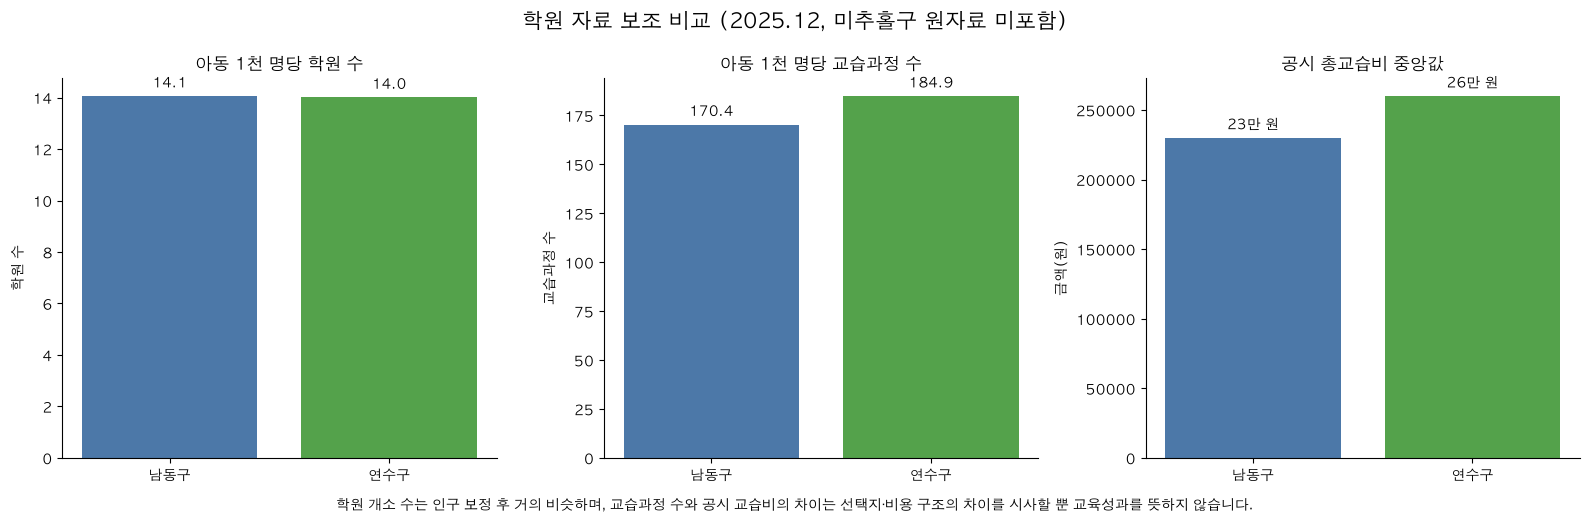

,학원 수,교습과정 수,공시 총교습비 중앙값,2025년_아동전체,아동 1천 명당 학원 수,아동 1천 명당 교습과정 수
구,,,,,,
남동구,829,10047,230000.0,58973,14.06,170.37
연수구,997,13164,260000.0,71191,14.00,184.91


In [35]:
ACADEMY_PATH = RAW_DATA_DIR / "2025-12-01_incheon_academy_status.csv"
if not ACADEMY_PATH.exists():
    raise FileNotFoundError(f"학원 CSV 파일을 찾을 수 없습니다: {ACADEMY_PATH}")

academy_df = pd.read_csv(ACADEMY_PATH, encoding="utf-8-sig")
academy_df.columns = academy_df.columns.astype(str).str.strip()
academy_df["학원주소"] = academy_df["학원주소"].astype(str).str.strip()
academy_df["구"] = academy_df["학원주소"].str.extract(r"인천광역시\s+(남동구|미추홀구|연수구)")
academy_df = academy_df.loc[academy_df["구"].notna()].copy()
academy_df["총교습비"] = pd.to_numeric(academy_df["총교습비"], errors="coerce")
academy_df["학원키"] = academy_df["학원명"].astype(str) + " | " + academy_df["학원주소"]

academy_summary = pd.DataFrame({
    "학원 수": academy_df.drop_duplicates("학원키").groupby("구").size(),
    "교습과정 수": academy_df.groupby("구").size(),
    "공시 총교습비 중앙값": academy_df.groupby("구")["총교습비"].median(),
}).join(population_summary[["2025년_아동전체"]])
academy_summary["아동 1천 명당 학원 수"] = academy_summary["학원 수"] / academy_summary["2025년_아동전체"] * 1_000
academy_summary["아동 1천 명당 교습과정 수"] = academy_summary["교습과정 수"] / academy_summary["2025년_아동전체"] * 1_000
academy_summary = academy_summary.reindex(["남동구", "연수구"])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
academy_plot = academy_summary.reset_index().rename(columns={"index": "구"})

for ax, column, title, ylabel, formatter in [
    (axes[0], "아동 1천 명당 학원 수", "아동 1천 명당 학원 수", "학원 수", lambda value: f"{value:.1f}"),
    (axes[1], "아동 1천 명당 교습과정 수", "아동 1천 명당 교습과정 수", "교습과정 수", lambda value: f"{value:.1f}"),
    (axes[2], "공시 총교습비 중앙값", "공시 총교습비 중앙값", "금액(원)", lambda value: f"{value / 10_000:.0f}만 원"),
]:
    bars = ax.bar(academy_plot["구"], academy_plot[column], color=[AREA_COLORS[area] for area in academy_plot["구"]])
    ax.bar_label(bars, labels=[formatter(value) for value in academy_plot[column]], padding=3)
    ax.set_title(title, weight="bold")
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("학원 자료 보조 비교 (2025.12, 미추홀구 원자료 미포함)", fontsize=15, weight="bold")
fig.text(0.5, -0.02, "학원 개소 수는 인구 보정 후 거의 비슷하며, 교습과정 수와 공시 교습비의 차이는 선택지·비용 구조의 차이를 시사할 뿐 교육성과를 뜻하지 않습니다.", ha="center", fontsize=10)
fig.tight_layout()
plt.show()
academy_summary.round(2)

## 종합 해석과 정책적 활용

이 분석이 보여 주는 것은 교육격차의 원인이나 학생 개인의 성취 차이가 아니라, **인구 규모와 공공·사교육 인프라의 공급 구조가 구마다 다를 수 있다는 점**입니다.

- 아동·청소년 인구가 많은 지역은 시설 수의 절대값보다 **아동 1천 명당 정원·과정 수**를 우선 확인합니다.
- 지역아동센터 정원은 공공 돌봄의 잠재 수용 역량입니다. 실제 이용률·대기자 수가 없으므로, 정원이 적다고 곧바로 서비스 부족으로 단정하지 않습니다.
- 학급당·교원당 학생 수는 학교 교육여건의 투입 지표입니다. 수치 차이는 학습 지원 여건을 점검할 근거가 되지만, 교육의 질이나 성취도 차이로 바로 해석하지 않습니다.
- 수급자 비율은 교육비 부담과 돌봄 수요를 추가로 살필 지역을 찾는 보조 지표입니다. 개인·가구의 소득 수준이나 학업성취를 의미하지 않습니다.
- 학원 자료는 미추홀구가 보완된 뒤에만 세 구의 동등한 비교에 사용합니다. 현재 그래프는 남동구·연수구의 보조적 현황 비교입니다.

따라서 다음 정책 질문은 ‘어느 구가 더 낫나’가 아니라, **아동 인구와 취약성에 비해 돌봄 정원·학습 선택지가 부족한 생활권은 어디이며 무엇을 보완해야 하는가**가 되어야 합니다.